## Setup and Imports

In [1]:
import os
import math
import random
import time
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True  # faster on GPU

seed_everything(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti


In [4]:
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)
os.makedirs("app", exist_ok=True)

print("Folders ready: models/, artifacts/, app/")

Folders ready: models/, artifacts/, app/


## Load Wikipedia via parquet export

In [5]:


from datasets import load_dataset

MAX_SAMPLES = 100_000
SEED = 42


raw_ds = load_dataset(
    "wikimedia/wikipedia",
    "20231101.en",     
    split="train"
)

print("Total rows:", len(raw_ds))
print("Columns:", raw_ds.column_names)

# shuffle + take subset
raw_ds = raw_ds.shuffle(seed=SEED).select(range(min(MAX_SAMPLES, len(raw_ds))))

# keep non-empty text only
raw_ds = raw_ds.filter(lambda x: isinstance(x["text"], str) and len(x["text"].strip()) > 0)

print("Subset rows after filter:", len(raw_ds))

# preview
for i in range(2):
    print("\n--- sample", i, "---")
    print(raw_ds[i]["text"][:400])


README.md: 0.00B [00:00, ?B/s]

c:\Users\gaurav\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gaurav\.cache\huggingface\hub\datasets--wikimedia--wikipedia. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

20231101.en/train-00000-of-00041.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

20231101.en/train-00001-of-00041.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/6407814 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/41 [00:00<?, ?it/s]

Total rows: 6407814
Columns: ['id', 'url', 'title', 'text']


Filter:   0%|          | 0/100000 [00:00<?, ? examples/s]

Subset rows after filter: 100000

--- sample 0 ---
HMP Hull is a Category B men's local prison located in Kingston upon Hull in England. The term 'local' means that this prison holds people on remand to the local courts. The prison is operated by His Majesty's Prison Service.

History
Hull Prison opened in 1870, and is of a typical Victorian design. 
Ethel Major was the last person and only woman to be executed at Hull in 1934. She had been convic

--- sample 1 ---
Lionel Edgar Charles Letts BEM (15 August 1918 – 23 October 2013) was an English entrepreneur notable for a 75-year career in Southeast Asia during which he took a role on the boards of more than 90 listed companies, survived torture, multiple escape attempts and a death sentence as a Japanese Prisoner of War and acted as a spy on behalf of the British Secret Intelligence Service.

Personal life
L


## Export corpus to artifacts/corpus_100k.txt

In [6]:


import os

os.makedirs("artifacts", exist_ok=True)
corpus_txt_path = "artifacts/corpus_100k.txt"

with open(corpus_txt_path, "w", encoding="utf-8") as f:
    for ex in raw_ds:
        # one cleaned article per line
        text = ex["text"].replace("\n", " ").strip()
        if text:
            f.write(text + "\n")

print("Saved corpus to:", corpus_txt_path)

#sanity check
with open(corpus_txt_path, "r", encoding="utf-8") as f:
    for i in range(2):
        print(f"\n--- line {i} preview ---")
        print(f.readline()[:300])


Saved corpus to: artifacts/corpus_100k.txt

--- line 0 preview ---
HMP Hull is a Category B men's local prison located in Kingston upon Hull in England. The term 'local' means that this prison holds people on remand to the local courts. The prison is operated by His Majesty's Prison Service.  History Hull Prison opened in 1870, and is of a typical Victorian design.

--- line 1 preview ---
Lionel Edgar Charles Letts BEM (15 August 1918 – 23 October 2013) was an English entrepreneur notable for a 75-year career in Southeast Asia during which he took a role on the boards of more than 90 listed companies, survived torture, multiple escape attempts and a death sentence as a Japanese Priso


## Train a BERT-style WordPiece tokenizer

In [7]:


import os
from tokenizers import BertWordPieceTokenizer

corpus_txt_path = "artifacts/corpus_100k.txt"
tokenizer_dir = "tokenizer"
os.makedirs(tokenizer_dir, exist_ok=True)

VOCAB_SIZE = 30_000   
MIN_FREQ  = 2

# Initialize a WordPiece tokenizer (BERT style)
wp_tokenizer = BertWordPieceTokenizer(
    clean_text=True,
    handle_chinese_chars=True,
    strip_accents=True,
    lowercase=True
)

# Train on your corpus
wp_tokenizer.train(
    files=[corpus_txt_path],
    vocab_size=VOCAB_SIZE,
    min_frequency=MIN_FREQ,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)

# Save as BERT vocab.txt (+ tokenizer config files)
wp_tokenizer.save_model(tokenizer_dir)
print("Saved tokenizer to:", tokenizer_dir)
print("Files:", os.listdir(tokenizer_dir))


Saved tokenizer to: tokenizer
Files: ['vocab.txt']


## Load your tokenizer + test encoding + get special token IDs

In [8]:


from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained(
    "tokenizer",
    do_lower_case=True
)

print("Vocab size:", tokenizer.vocab_size)

# Special token IDs 
PAD_ID  = tokenizer.pad_token_id
UNK_ID  = tokenizer.unk_token_id
CLS_ID  = tokenizer.cls_token_id
SEP_ID  = tokenizer.sep_token_id
MASK_ID = tokenizer.mask_token_id

print("PAD:", PAD_ID, "UNK:", UNK_ID, "CLS:", CLS_ID, "SEP:", SEP_ID, "MASK:", MASK_ID)


s = "BERT learns bidirectional context using masked language modeling."
enc = tokenizer(s, return_tensors="pt")
print("\nInput IDs shape:", enc["input_ids"].shape)
print("Tokens:", tokenizer.convert_ids_to_tokens(enc["input_ids"][0][:30].tolist()))


Vocab size: 30000
PAD: 0 UNK: 1 CLS: 2 SEP: 3 MASK: 4

Input IDs shape: torch.Size([1, 13])
Tokens: ['[CLS]', 'bert', 'learns', 'bid', '##irect', '##ional', 'context', 'using', 'masked', 'language', 'modeling', '.', '[SEP]']


## MLM masking logic (BERT rules) + Dataset skeleton

In [9]:
from torch.utils.data import Dataset

MAX_LEN = 128    
MLM_PROB = 0.15

SPECIAL_IDS = set([PAD_ID, CLS_ID, SEP_ID])

def mask_tokens(input_ids: torch.Tensor, mlm_prob: float = MLM_PROB):
    """
    input_ids: LongTensor [T] (single sequence)
    returns:
      masked_input_ids: LongTensor [T]
      labels: LongTensor [T] with -100 for non-mlm positions
    """
    input_ids = input_ids.clone()
    labels = input_ids.clone()

    # Candidate positions: not special, not pad
    can_mask = torch.ones_like(input_ids, dtype=torch.bool)
    for sid in SPECIAL_IDS:
        can_mask &= (input_ids != sid)
    can_mask &= (input_ids != PAD_ID)

    # Choose mask positions
    rand = torch.rand(input_ids.shape)
    mask_positions = (rand < mlm_prob) & can_mask

    # Labels: only compute loss on masked positions
    labels[~mask_positions] = -100

    # Apply BERT masking strategy
    # 80% -> [MASK]
    probs = torch.rand(input_ids.shape)

    mask_80 = mask_positions & (probs < 0.80)
    input_ids[mask_80] = MASK_ID

    # 10% -> random token
    mask_10_rand = mask_positions & (probs >= 0.80) & (probs < 0.90)
    random_tokens = torch.randint(low=0, high=tokenizer.vocab_size, size=input_ids.shape)
    input_ids[mask_10_rand] = random_tokens[mask_10_rand]

    # 10% -> keep original (do nothing)

    return input_ids, labels


class MLMDataset(Dataset):
    """
    Takes raw wikipedia text dataset (raw_ds) and produces tokenized sequences for MLM.
    We'll keep it simple: each example is one text chunk tokenized to MAX_LEN.
    """
    def __init__(self, hf_dataset, tokenizer, max_len=128):
        self.ds = hf_dataset
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        text = self.ds[idx]["text"]

        enc = self.tok(
            text,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )

        input_ids = enc["input_ids"][0]          # [T]
        attention_mask = enc["attention_mask"][0]  # [T]

        masked_ids, labels = mask_tokens(input_ids)

        return {
            "input_ids": masked_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

print("MLM dataset ready.")


MLM dataset ready.


## DataLoader + sanity-check a batch

In [10]:

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_ds = MLMDataset(raw_ds, tokenizer, max_len=MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

batch = next(iter(train_loader))

input_ids = batch["input_ids"]           # [B, T]
attn_mask = batch["attention_mask"]      # [B, T]
labels    = batch["labels"]              # [B, T]

print("Batch shapes:")
print(" input_ids:", input_ids.shape)
print(" attention_mask:", attn_mask.shape)
print(" labels:", labels.shape)

# Count masked positions (labels != -100)
masked_count = (labels != -100).sum().item()
total_tokens = labels.numel()
print(f"\nMasked tokens: {masked_count} / {total_tokens} ({masked_count/total_tokens*100:.2f}%)")

# Visual check for one example
i = 0
tokens_in = tokenizer.convert_ids_to_tokens(input_ids[i].tolist())
tokens_lbl = tokenizer.convert_ids_to_tokens(
    torch.where(labels[i] != -100, labels[i], torch.tensor(PAD_ID)).tolist()
)

print("\n--- Example 0 (first 60 tokens) ---")
print("INPUT :", tokens_in[:60])
print("LABELS:", tokens_lbl[:60])

# Decode (note: decode will remove special formatting)
print("\nDecoded input preview:")
print(tokenizer.decode(input_ids[i], skip_special_tokens=True)[:300])


Batch shapes:
 input_ids: torch.Size([32, 128])
 attention_mask: torch.Size([32, 128])
 labels: torch.Size([32, 128])

Masked tokens: 568 / 4096 (13.87%)

--- Example 0 (first 60 tokens) ---
INPUT : ['[CLS]', 'vic', '##anci', '(', ')', '[MASK]', 'a', 'settlement', 'in', 'the', 'slovene', 'hills', 'northwest', 'of', 'or', '##mo', '##z', 'in', 'northeastern', 'slovenia', '[MASK]', 'the', 'area', 'belongs', 'to', '[MASK]', 'traditional', '[MASK]', 'of', 'sty', '##ria', '.', 'it', 'is', 'now', 'included', 'in', 'the', 'drav', '##a', 'statistical', 'region', '.', 'there', 'is', 'a', '##ionage', 'roads', '[MASK]', 'chapel', 'with', 'a', 'bel', '##fr', '##y', '[MASK]', 'the', 'northern', 'part', 'of']
LABELS: ['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', 'is', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '.', '[PAD]', '[PAD]', '[PAD]', '[PAD]', 'the', '[PAD]', 'region', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]'

## BERT (from scratch): Config + Embeddings + Transformer Encoder Block

In [11]:
from dataclasses import dataclass

@dataclass
class BertConfigScratch:
    vocab_size: int
    max_len: int = 128

    # model size (small for assignment speed; you can scale later)
    hidden_size: int = 256
    num_heads: int = 4
    num_layers: int = 4
    intermediate_size: int = 1024

    dropout: float = 0.1
    layer_norm_eps: float = 1e-12


class BertEmbeddings(nn.Module):
    def __init__(self, cfg: BertConfigScratch):
        super().__init__()
        self.word_embeddings = nn.Embedding(cfg.vocab_size, cfg.hidden_size, padding_idx=PAD_ID)
        self.position_embeddings = nn.Embedding(cfg.max_len, cfg.hidden_size)
        self.token_type_embeddings = nn.Embedding(2, cfg.hidden_size)  # sentence A/B (we keep, even if unused)

        self.layer_norm = nn.LayerNorm(cfg.hidden_size, eps=cfg.layer_norm_eps)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, input_ids, token_type_ids=None):
        # input_ids: [B, T]
        B, T = input_ids.shape
        if token_type_ids is None:
            token_type_ids = torch.zeros((B, T), dtype=torch.long, device=input_ids.device)

        positions = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)

        x = (
            self.word_embeddings(input_ids)
            + self.position_embeddings(positions)
            + self.token_type_embeddings(token_type_ids)
        )
        x = self.layer_norm(x)
        x = self.dropout(x)
        return x


class TransformerEncoderLayer(nn.Module):
    def __init__(self, cfg: BertConfigScratch):
        super().__init__()
        assert cfg.hidden_size % cfg.num_heads == 0, "hidden_size must be divisible by num_heads"

        self.self_attn = nn.MultiheadAttention(
            embed_dim=cfg.hidden_size,
            num_heads=cfg.num_heads,
            dropout=cfg.dropout,
            batch_first=True
        )

        self.attn_ln = nn.LayerNorm(cfg.hidden_size, eps=cfg.layer_norm_eps)
        self.attn_dropout = nn.Dropout(cfg.dropout)

        self.ffn = nn.Sequential(
            nn.Linear(cfg.hidden_size, cfg.intermediate_size),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.intermediate_size, cfg.hidden_size),
        )

        self.ffn_ln = nn.LayerNorm(cfg.hidden_size, eps=cfg.layer_norm_eps)
        self.ffn_dropout = nn.Dropout(cfg.dropout)

    def forward(self, x, attention_mask):
        """
        x: [B, T, H]
        attention_mask: [B, T] where 1 = keep, 0 = pad
        """
        # key_padding_mask: True means "ignore" in PyTorch MHA
        key_padding_mask = (attention_mask == 0)

        attn_out, _ = self.self_attn(
            query=x, key=x, value=x,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )

        # Residual + LN
        x = self.attn_ln(x + self.attn_dropout(attn_out))

        # FFN
        ffn_out = self.ffn(x)
        x = self.ffn_ln(x + self.ffn_dropout(ffn_out))
        return x


class BertEncoderScratch(nn.Module):
    def __init__(self, cfg: BertConfigScratch):
        super().__init__()
        self.cfg = cfg
        self.emb = BertEmbeddings(cfg)
        self.layers = nn.ModuleList([TransformerEncoderLayer(cfg) for _ in range(cfg.num_layers)])

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        x = self.emb(input_ids, token_type_ids=token_type_ids)
        for layer in self.layers:
            x = layer(x, attention_mask)
        return x  # [B, T, H]


# Instantiate encoder (small)
cfg = BertConfigScratch(vocab_size=tokenizer.vocab_size, max_len=MAX_LEN)
encoder = BertEncoderScratch(cfg).to(device)

print("BERT encoder created.")
print("Params:", sum(p.numel() for p in encoder.parameters())/1e6, "M")


BERT encoder created.
Params: 10.872832 M


## Add MLM head + full BERT-MLM model + forward test

In [12]:

class BertMLMHead(nn.Module):
    def __init__(self, cfg: BertConfigScratch):
        super().__init__()
        self.dense = nn.Linear(cfg.hidden_size, cfg.hidden_size)
        self.act = nn.GELU()
        self.ln = nn.LayerNorm(cfg.hidden_size, eps=cfg.layer_norm_eps)

        # vocab projection
        self.decoder = nn.Linear(cfg.hidden_size, cfg.vocab_size, bias=False)
        self.bias = nn.Parameter(torch.zeros(cfg.vocab_size))

    def forward(self, x):
        # x: [B, T, H]
        x = self.dense(x)
        x = self.act(x)
        x = self.ln(x)
        logits = self.decoder(x) + self.bias  # [B, T, V]
        return logits


class BertForMLMScratch(nn.Module):
    def __init__(self, cfg: BertConfigScratch):
        super().__init__()
        self.cfg = cfg
        self.encoder = BertEncoderScratch(cfg)
        self.mlm_head = BertMLMHead(cfg)

        # Weight tying : share input embedding weights with output decoder
        self.mlm_head.decoder.weight = self.encoder.emb.word_embeddings.weight

    def forward(self, input_ids, attention_mask, labels=None):
        x = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.mlm_head(x)

        loss = None
        if labels is not None:
            # CrossEntropy expects [N, C] and labels [N]
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        return {"loss": loss, "log labels": labels, "logits": logits}


# Build full model
mlm_model = BertForMLMScratch(cfg).to(device)
print("BERT-MLM model ready.")
print("Params:", sum(p.numel() for p in mlm_model.parameters())/1e6, "M")

# ---- Forward sanity test on one batch ----
batch = next(iter(train_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

out = mlm_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
print("Forward OK. Loss:", float(out["loss"]))
print("Logits shape:", out["logits"].shape)


BERT-MLM model ready.
Params: 10.969136 M
Forward OK. Loss: 67.58876037597656
Logits shape: torch.Size([32, 128, 30000])


## Training loop for MLM (optimizer + scheduler + logging)

In [13]:
# ===== Cell A: MLM training (epoch-level logs + history) =====
from transformers import get_linear_schedule_with_warmup
import time, torch
import torch.nn.functional as F

def masked_accuracy(logits, labels):
    with torch.no_grad():
        pred = logits.argmax(dim=-1)
        mask = (labels != -100)
        if mask.sum().item() == 0:
            return 0.0
        return (pred[mask] == labels[mask]).float().mean().item()

def train_mlm_epochs(model, loader, epochs=3, lr=5e-4, weight_decay=0.01,
                     warmup_ratio=0.1, grad_clip=1.0, max_steps_per_epoch=1000):
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    steps_per_epoch = min(len(loader), max_steps_per_epoch)
    total_steps = steps_per_epoch * epochs
    warmup_steps = int(total_steps * warmup_ratio)

    sched = get_linear_schedule_with_warmup(opt, warmup_steps, total_steps)

    print(f"steps_per_epoch: {steps_per_epoch}")
    print(f"total_steps: {total_steps} warmup_steps: {warmup_steps}")

    hist = {"loss": [], "masked_acc": []}

    for ep in range(1, epochs + 1):
        t0 = time.time()
        run_loss, run_acc = 0.0, 0.0

        for step, batch in enumerate(loader):
            if step >= steps_per_epoch:
                break

            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            opt.zero_grad(set_to_none=True)
            out = model(input_ids=input_ids, attention_mask=attn, labels=labels)
            loss = out["loss"]
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            opt.step()
            sched.step()

            run_loss += loss.item()
            run_acc += masked_accuracy(out["logits"], labels)

        avg_loss = run_loss / steps_per_epoch
        avg_acc = run_acc / steps_per_epoch
        hist["loss"].append(avg_loss)
        hist["masked_acc"].append(avg_acc)

        print(f"Epoch {ep:02d} | loss {avg_loss:.4f} | masked-acc {avg_acc:.4f} | time {time.time()-t0:.1f}s")

    print("Training finished.")
    return hist

# Run it:
mlm_hist = train_mlm_epochs(mlm_model, train_loader, epochs=15)


steps_per_epoch: 1000
total_steps: 15000 warmup_steps: 1500
Epoch 01 | loss 23.4913 | masked-acc 0.0471 | time 241.6s
Epoch 02 | loss 8.0657 | masked-acc 0.1185 | time 242.5s
Epoch 03 | loss 7.0495 | masked-acc 0.1363 | time 232.8s
Epoch 04 | loss 6.8442 | masked-acc 0.1468 | time 232.6s
Epoch 05 | loss 6.7261 | masked-acc 0.1556 | time 237.1s
Epoch 06 | loss 6.6212 | masked-acc 0.1652 | time 258.1s
Epoch 07 | loss 6.5430 | masked-acc 0.1743 | time 262.2s
Epoch 08 | loss 6.4669 | masked-acc 0.1834 | time 262.2s
Epoch 09 | loss 6.3804 | masked-acc 0.1947 | time 264.7s
Epoch 10 | loss 6.2367 | masked-acc 0.2174 | time 264.1s
Epoch 11 | loss 6.0677 | masked-acc 0.2402 | time 262.4s
Epoch 12 | loss 5.9633 | masked-acc 0.2516 | time 240.8s
Epoch 13 | loss 5.8835 | masked-acc 0.2590 | time 245.8s
Epoch 14 | loss 5.8293 | masked-acc 0.2650 | time 251.9s
Epoch 15 | loss 5.7933 | masked-acc 0.2687 | time 246.6s
Training finished.


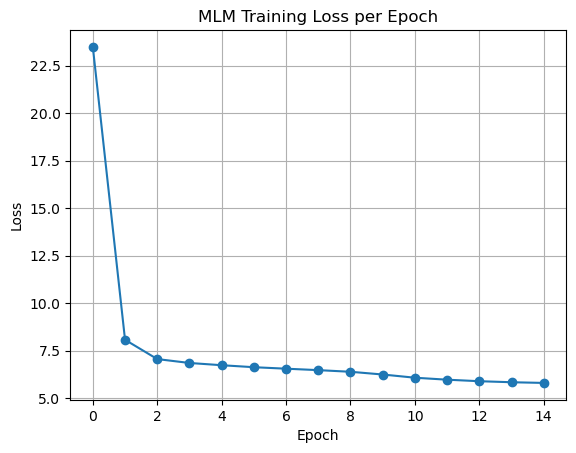

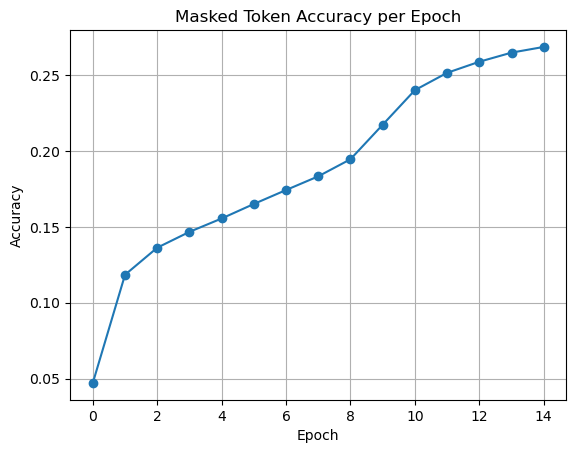

In [14]:
import matplotlib.pyplot as plt

# ---- Loss curve ----
plt.figure()
plt.plot(mlm_hist["loss"], marker="o")
plt.title("MLM Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ---- Accuracy curve ----
plt.figure()
plt.plot(mlm_hist["masked_acc"], marker="o")
plt.title("Masked Token Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


## Save pretrained BERT encoder

In [15]:
import json
import torch
import os

os.makedirs("models", exist_ok=True)

save_path = "models/bert_scratch_mlm.pt"
meta_path = "models/bert_scratch_mlm_meta.json"

# Save weights
torch.save(
    {
        "state_dict": mlm_model.state_dict(),   # includes encoder + MLM head
    },
    save_path
)

# Save metadata needed for loading
meta = {
    "vocab_size": cfg.vocab_size,
    "max_len": cfg.max_len,
    "hidden_size": cfg.hidden_size,
    "num_heads": cfg.num_heads,
    "num_layers": cfg.num_layers,
    "intermediate_size": cfg.intermediate_size,
    "dropout": cfg.dropout,
    "layer_norm_eps": cfg.layer_norm_eps,

    "special_ids": {
        "PAD_ID": PAD_ID,
        "UNK_ID": UNK_ID,
        "CLS_ID": CLS_ID,
        "SEP_ID": SEP_ID,
        "MASK_ID": MASK_ID
    },

    "tokenizer_dir": "tokenizer",
    "trained_on": "wikimedia/wikipedia subset (~100k) exported to artifacts/corpus_100k.txt"
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Saved model weights to:", save_path)
print("Saved metadata to:", meta_path)


Saved model weights to: models/bert_scratch_mlm.pt
Saved metadata to: models/bert_scratch_mlm_meta.json


## Load SNLI (premise, hypothesis, label) + clean it

In [16]:

from datasets import load_dataset

# SNLI labels: 0=entailment, 1=neutral, 2=contradiction, -1=invalid
label_map = {0: "entailment", 1: "neutral", 2: "contradiction"}

snli = load_dataset("snli")

print(snli)
print("Train size:", len(snli["train"]))
print("Validation size:", len(snli["validation"]))
print("Test size:", len(snli["test"]))
print("Columns:", snli["train"].column_names)

def clean_snli(example):
    # keep only valid labels + non-empty texts
    if example["label"] not in (0, 1, 2):
        return False
    if not isinstance(example["premise"], str) or not example["premise"].strip():
        return False
    if not isinstance(example["hypothesis"], str) or not example["hypothesis"].strip():
        return False
    return True

snli_train = snli["train"].filter(clean_snli)
snli_val   = snli["validation"].filter(clean_snli)
snli_test  = snli["test"].filter(clean_snli)

print("\nAfter cleaning:")
print("Train:", len(snli_train), "Val:", len(snli_val), "Test:", len(snli_test))

# Quick peek
for i in range(2):
    ex = snli_train[i]
    print("\n--- example", i, "---")
    print("Premise   :", ex["premise"][:200])
    print("Hypothesis:", ex["hypothesis"][:200])
    print("Label     :", ex["label"], "=", label_map[ex["label"]])


README.md: 0.00B [00:00, ?B/s]

c:\Users\gaurav\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gaurav\.cache\huggingface\hub\datasets--snli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/412k [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/413k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

...

DatasetDict({
    test: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 550152
    })
})
Train size: 550152
Validation size: 10000
Test size: 10000
Columns: ['premise', 'hypothesis', 'label']


Filter:   0%|          | 0/550152 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]


After cleaning:
Train: 549367 Val: 9842 Test: 9824

--- example 0 ---
Premise   : A person on a horse jumps over a broken down airplane.
Hypothesis: A person is training his horse for a competition.
Label     : 1 = neutral

--- example 1 ---
Premise   : A person on a horse jumps over a broken down airplane.
Hypothesis: A person is at a diner, ordering an omelette.
Label     : 2 = contradiction


## Tokenize sentence pairs (premise, hypothesis) + DataLoaders

In [17]:

from torch.utils.data import Dataset, DataLoader

MAX_LEN_NLI = 128
BATCH_SIZE_NLI = 32

class NLIPairDataset(Dataset):
    def __init__(self, hf_ds, tokenizer, max_len=128):
        self.ds = hf_ds
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        premise = ex["premise"]
        hypothesis = ex["hypothesis"]
        label = int(ex["label"])

        enc = self.tok(
            premise,
            hypothesis,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"][0],
            "attention_mask": enc["attention_mask"][0],
            "token_type_ids": enc.get("token_type_ids", torch.zeros_like(enc["input_ids"][0])),
            "label": torch.tensor(label, dtype=torch.long)
        }

train_nli_ds = NLIPairDataset(snli_train, tokenizer, max_len=MAX_LEN_NLI)
val_nli_ds   = NLIPairDataset(snli_val, tokenizer, max_len=MAX_LEN_NLI)
test_nli_ds  = NLIPairDataset(snli_test, tokenizer, max_len=MAX_LEN_NLI)

train_nli_loader = DataLoader(train_nli_ds, batch_size=BATCH_SIZE_NLI, shuffle=True)
val_nli_loader   = DataLoader(val_nli_ds, batch_size=BATCH_SIZE_NLI, shuffle=False)
test_nli_loader  = DataLoader(test_nli_ds, batch_size=BATCH_SIZE_NLI, shuffle=False)


b = next(iter(train_nli_loader))
print("Batch shapes:")
print(" input_ids:", b["input_ids"].shape)
print(" attention_mask:", b["attention_mask"].shape)
print(" token_type_ids:", b["token_type_ids"].shape)
print(" label:", b["label"].shape)

# Decode preview
i = 0
print("\nDecoded pair preview:")
print(tokenizer.decode(b["input_ids"][i], skip_special_tokens=False)[:250])
print("Label:", int(b["label"][i]), "=", label_map[int(b["label"][i])])


Batch shapes:
 input_ids: torch.Size([32, 128])
 attention_mask: torch.Size([32, 128])
 token_type_ids: torch.Size([32, 1, 128])
 label: torch.Size([32])

Decoded pair preview:
[CLS] the barefoot woman in sunglasses sits in the tree. [SEP] a woman sits in a chair. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] 
Label: 2 = contradiction


## Load your pretrained BERT + build Siamese SBERT + SoftmaxLoss head

In [18]:

import json
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------- Load metadata --------
with open("models/bert_scratch_mlm_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

cfg_sbert = BertConfigScratch(
    vocab_size=meta["vocab_size"],
    max_len=meta["max_len"],
    hidden_size=meta["hidden_size"],
    num_heads=meta["num_heads"],
    num_layers=meta["num_layers"],
    intermediate_size=meta["intermediate_size"],
    dropout=meta["dropout"],
    layer_norm_eps=meta["layer_norm_eps"],
)

# -------- Rebuild model (same architecture) --------
mlm_model_loaded = BertForMLMScratch(cfg_sbert).to(device)

ckpt = torch.load("models/bert_scratch_mlm.pt", map_location=device)
mlm_model_loaded.load_state_dict(ckpt["state_dict"], strict=True)
mlm_model_loaded.eval()

print("Loaded pretrained BERT weights ")

# We only need the encoder for SBERT
bert_encoder = mlm_model_loaded.encoder  # shared encoder


# -------- Pooling: mean pooling (recommended for sentence embeddings) --------
def mean_pooling(token_embeddings, attention_mask):
    """
    token_embeddings: [B, T, H]
    attention_mask:   [B, T] where 1=real token, 0=pad
    """
    mask = attention_mask.unsqueeze(-1).float()  # [B, T, 1]
    summed = (token_embeddings * mask).sum(dim=1)              # [B, H]
    counts = mask.sum(dim=1).clamp(min=1e-9)                   # [B, 1]
    return summed / counts                                     # [B, H]


# -------- Siamese SBERT model with Softmax head --------
class SBERTSoftmaxNLI(nn.Module):
    def __init__(self, encoder: BertEncoderScratch, hidden_size: int, num_labels: int = 3, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(dropout)

        # (u, v, |u-v|) => dimension = 3 * hidden_size
        self.classifier = nn.Linear(3 * hidden_size, num_labels)

    def encode(self, input_ids, attention_mask, token_type_ids=None):
        # returns sentence embedding u: [B, H]
        x = self.encoder(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        u = mean_pooling(x, attention_mask)
        return u

    def forward(self, a_ids, a_mask, b_ids, b_mask):
        u = self.encode(a_ids, a_mask)
        v = self.encode(b_ids, b_mask)

        feats = torch.cat([u, v, torch.abs(u - v)], dim=-1)   # [B, 3H]
        feats = self.dropout(feats)
        logits = self.classifier(feats)                       # [B, 3]
        return logits


sbert_model = SBERTSoftmaxNLI(
    encoder=bert_encoder,
    hidden_size=cfg_sbert.hidden_size,
    num_labels=3,
    dropout=cfg_sbert.dropout
).to(device)

print("SBERT siamese model ready")
print("Params:", sum(p.numel() for p in sbert_model.parameters())/1e6, "M")


Loaded pretrained BERT weights 
SBERT siamese model ready
Params: 10.875139 M


## SBERT-style dataset (separate encoding for premise & hypothesis) + DataLoaders

In [19]:

from torch.utils.data import Dataset, DataLoader

MAX_LEN_SIAMESE = 128
BATCH_SIZE_SIAMESE = 32

class SbertNLIDataset(Dataset):
    def __init__(self, hf_ds, tokenizer, max_len=128):
        self.ds = hf_ds
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        premise = ex["premise"]
        hypothesis = ex["hypothesis"]
        label = int(ex["label"])

        a = self.tok(
            premise,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )
        b = self.tok(
            hypothesis,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "a_input_ids": a["input_ids"][0],
            "a_attention_mask": a["attention_mask"][0],
            "b_input_ids": b["input_ids"][0],
            "b_attention_mask": b["attention_mask"][0],
            "label": torch.tensor(label, dtype=torch.long),
        }

train_siamese_ds = SbertNLIDataset(snli_train, tokenizer, max_len=MAX_LEN_SIAMESE)
val_siamese_ds   = SbertNLIDataset(snli_val, tokenizer, max_len=MAX_LEN_SIAMESE)
test_siamese_ds  = SbertNLIDataset(snli_test, tokenizer, max_len=MAX_LEN_SIAMESE)

train_siamese_loader = DataLoader(train_siamese_ds, batch_size=BATCH_SIZE_SIAMESE, shuffle=True)
val_siamese_loader   = DataLoader(val_siamese_ds, batch_size=BATCH_SIZE_SIAMESE, shuffle=False)
test_siamese_loader  = DataLoader(test_siamese_ds, batch_size=BATCH_SIZE_SIAMESE, shuffle=False)

# ---- Sanity check forward pass ----
b = next(iter(train_siamese_loader))

a_ids = b["a_input_ids"].to(device)
a_mask = b["a_attention_mask"].to(device)
b_ids = b["b_input_ids"].to(device)
b_mask = b["b_attention_mask"].to(device)

logits = sbert_model(a_ids, a_mask, b_ids, b_mask)
print("Logits shape:", logits.shape)  # [B, 3]

print("Example label:", int(b["label"][0]), "=", label_map[int(b["label"][0])])
print("Premise:", tokenizer.decode(b["a_input_ids"][0], skip_special_tokens=True)[:120])
print("Hypothesis:", tokenizer.decode(b["b_input_ids"][0], skip_special_tokens=True)[:120])


Logits shape: torch.Size([32, 3])
Example label: 0 = entailment
Premise: a person wearing a mask fights another person with a bamboo sword.
Hypothesis: there are two people fighting


## Train SBERT (Softmax NLI) with epoch-level logging + loss curves

In [20]:

import matplotlib.pyplot as plt

def run_eval_sbert(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for batch in loader:
            a_ids = batch["a_input_ids"].to(device)
            a_mask = batch["a_attention_mask"].to(device)
            b_ids = batch["b_input_ids"].to(device)
            b_mask = batch["b_attention_mask"].to(device)
            y = batch["label"].to(device)

            logits = model(a_ids, a_mask, b_ids, b_mask)
            loss = F.cross_entropy(logits, y)

            total_loss += loss.item() * y.size(0)
            preds = logits.argmax(dim=-1)
            total_correct += (preds == y).sum().item()
            total_count += y.size(0)

    return total_loss / total_count, total_correct / total_count


# ---- Hyperparams ----
EPOCHS_SIAMESE = 15
LR_SIAMESE = 2e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
MAX_STEPS_PER_EPOCH = 1000  



sbert_model.train()

optimizer = torch.optim.AdamW(sbert_model.parameters(), lr=LR_SIAMESE, weight_decay=WEIGHT_DECAY)

steps_per_epoch = min(len(train_siamese_loader), MAX_STEPS_PER_EPOCH)
total_steps = steps_per_epoch * EPOCHS_SIAMESE
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("steps_per_epoch:", steps_per_epoch, "| total_steps:", total_steps, "| warmup:", warmup_steps)

# ---- History ----
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, EPOCHS_SIAMESE + 1):
    t0 = time.time()
    sbert_model.train()

    running_loss = 0.0
    running_correct = 0
    running_count = 0

    for step, batch in enumerate(train_siamese_loader):
        if step >= steps_per_epoch:
            break

        a_ids = batch["a_input_ids"].to(device)
        a_mask = batch["a_attention_mask"].to(device)
        b_ids = batch["b_input_ids"].to(device)
        b_mask = batch["b_attention_mask"].to(device)
        y = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = sbert_model(a_ids, a_mask, b_ids, b_mask)
        loss = F.cross_entropy(logits, y)
        loss.backward()

        nn.utils.clip_grad_norm_(sbert_model.parameters(), GRAD_CLIP)

        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=-1)
        running_correct += (preds == y).sum().item()
        running_count += y.size(0)

    train_loss = running_loss / running_count
    train_acc = running_correct / running_count

    val_loss, val_acc = run_eval_sbert(sbert_model, val_siamese_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
        f"time {time.time()-t0:.1f}s"
    )

print("SBERT training finished ")


steps_per_epoch: 1000 | total_steps: 15000 | warmup: 1500
Epoch 01 | train loss 1.0301 acc 0.4634 | val loss 0.9577 acc 0.5432 | time 136.5s
Epoch 02 | train loss 0.9311 acc 0.5558 | val loss 0.8679 acc 0.6041 | time 135.7s
Epoch 03 | train loss 0.8693 acc 0.5992 | val loss 0.8087 acc 0.6493 | time 135.8s
Epoch 04 | train loss 0.8291 acc 0.6264 | val loss 0.7755 acc 0.6612 | time 138.6s
Epoch 05 | train loss 0.8065 acc 0.6418 | val loss 0.7571 acc 0.6771 | time 163.1s
Epoch 06 | train loss 0.7867 acc 0.6537 | val loss 0.7371 acc 0.6810 | time 162.2s
Epoch 07 | train loss 0.7640 acc 0.6663 | val loss 0.7140 acc 0.6926 | time 162.5s
Epoch 08 | train loss 0.7551 acc 0.6722 | val loss 0.7091 acc 0.6968 | time 159.3s
Epoch 09 | train loss 0.7379 acc 0.6832 | val loss 0.6958 acc 0.7087 | time 152.5s
Epoch 10 | train loss 0.7329 acc 0.6843 | val loss 0.6790 acc 0.7162 | time 147.7s
Epoch 11 | train loss 0.7185 acc 0.6907 | val loss 0.6790 acc 0.7138 | time 147.6s
Epoch 12 | train loss 0.7039 

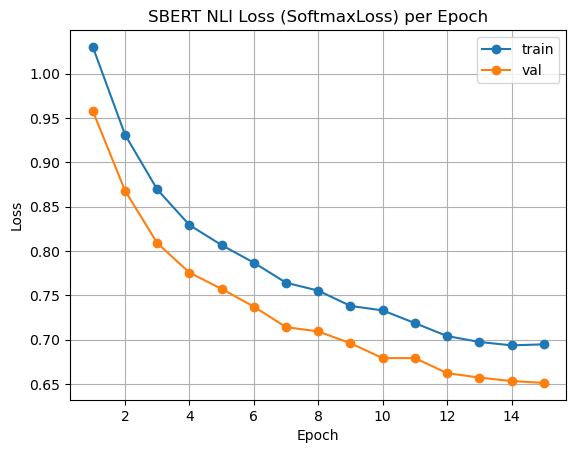

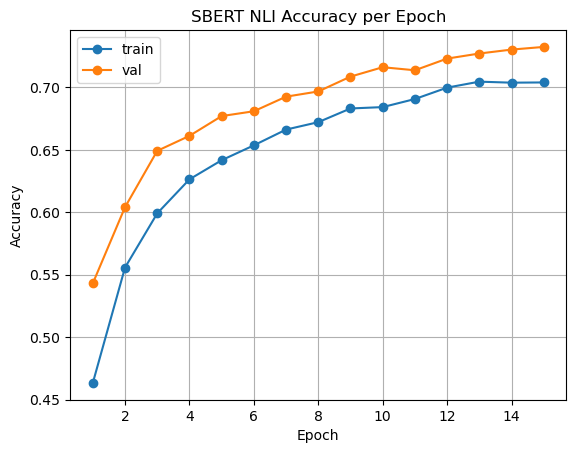

In [21]:

import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

# Loss curves
plt.figure()
plt.plot(epochs, train_losses, marker="o", label="train")
plt.plot(epochs, val_losses, marker="o", label="val")
plt.title("SBERT NLI Loss (SoftmaxLoss) per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Accuracy curves
plt.figure()
plt.plot(epochs, train_accs, marker="o", label="train")
plt.plot(epochs, val_accs, marker="o", label="val")
plt.title("SBERT NLI Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


## Test-set evaluation + Classification Report

In [22]:


import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def predict_all(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            a_ids = batch["a_input_ids"].to(device)
            a_mask = batch["a_attention_mask"].to(device)
            b_ids = batch["b_input_ids"].to(device)
            b_mask = batch["b_attention_mask"].to(device)
            y = batch["label"].to(device)

            logits = model(a_ids, a_mask, b_ids, b_mask)
            preds = logits.argmax(dim=-1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return all_preds, all_labels

y_pred, y_true = predict_all(sbert_model, test_siamese_loader)

print("Test accuracy:", accuracy_score(y_true, y_pred))

target_names = ["entailment", "neutral", "contradiction"]
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred))


Test accuracy: 0.7256718241042345

Classification Report:
               precision    recall  f1-score   support

   entailment     0.7347    0.7936    0.7631      3368
      neutral     0.6973    0.6440    0.6696      3219
contradiction     0.7417    0.7362    0.7389      3237

     accuracy                         0.7257      9824
    macro avg     0.7246    0.7246    0.7238      9824
 weighted avg     0.7248    0.7257    0.7245      9824

Confusion Matrix (rows=true, cols=pred):
[[2673  429  266]
 [ 582 2073  564]
 [ 383  471 2383]]


In [23]:
# Cosine similarity test for SBERT embeddings

import torch
import torch.nn.functional as F
import numpy as np

def encode_sentence(sentence: str):
    """
    Returns L2-normalized SBERT embedding vector.
    """
    sbert_model.eval()

    enc = tokenizer(
        sentence,
        truncation=True,
        max_length=MAX_LEN_SIAMESE,
        padding="max_length",
        return_tensors="pt"
    )

    ids = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        # Use encoder + mean pooling
        token_emb = sbert_model.encoder(ids, mask)
        sent_emb = mean_pooling(token_emb, mask)

        
        sent_emb = F.normalize(sent_emb, p=2, dim=1)

    return sent_emb[0].cpu().numpy()


def cosine_sim(a, b):
    return float(np.dot(a, b))


# -------- Test sentence pairs --------
pairs = [
    # Similar (entailment-like)
    ("A man is playing guitar on stage.", "A person is performing music."),
    ("A woman is cooking food.", "Someone is preparing a meal."),
    
    # Neutral
    ("A child is reading a book.", "A dog is running in the park."),
    
    # Contradiction / dissimilar
    ("Kids are swimming in a pool.", "No one is in the water."),
    ("A man is riding a bicycle.", "The man is sleeping in bed."),
]

print("=== Cosine Similarity Test ===\n")

for s1, s2 in pairs:
    e1 = encode_sentence(s1)
    e2 = encode_sentence(s2)
    sim = cosine_sim(e1, e2)

    print(f"Sentence A: {s1}")
    print(f"Sentence B: {s2}")
    print(f"Cosine similarity: {sim:.4f}")
    print("-" * 60)


=== Cosine Similarity Test ===

Sentence A: A man is playing guitar on stage.
Sentence B: A person is performing music.
Cosine similarity: 0.5365
------------------------------------------------------------
Sentence A: A woman is cooking food.
Sentence B: Someone is preparing a meal.
Cosine similarity: 0.4192
------------------------------------------------------------
Sentence A: A child is reading a book.
Sentence B: A dog is running in the park.
Cosine similarity: 0.1074
------------------------------------------------------------
Sentence A: Kids are swimming in a pool.
Sentence B: No one is in the water.
Cosine similarity: 0.3975
------------------------------------------------------------
Sentence A: A man is riding a bicycle.
Sentence B: The man is sleeping in bed.
Cosine similarity: 0.2908
------------------------------------------------------------


In [24]:
# Average cosine for similar vs dissimilar
similar_scores = []
dissimilar_scores = []

for s1, s2 in pairs[:2]:
    similar_scores.append(cosine_sim(encode_sentence(s1), encode_sentence(s2)))

for s1, s2 in pairs[-2:]:
    dissimilar_scores.append(cosine_sim(encode_sentence(s1), encode_sentence(s2)))

print("\nAverage cosine (similar):", np.mean(similar_scores))
print("Average cosine (dissimilar):", np.mean(dissimilar_scores))



Average cosine (similar): 0.47786369919776917
Average cosine (dissimilar): 0.3441486060619354


## Save SBERT model + build a reusable

In [25]:


import json
import torch
import os

os.makedirs("models", exist_ok=True)

SBERT_PATH = "models/sbert_softmax_snli.pt"
SBERT_META = "models/sbert_softmax_snli_meta.json"

torch.save({"state_dict": sbert_model.state_dict()}, SBERT_PATH)

meta_sbert = {
    "bert_meta_path": "models/bert_scratch_mlm_meta.json",
    "bert_ckpt_path": "models/bert_scratch_mlm.pt",
    "sbert_ckpt_path": SBERT_PATH,
    "pooling": "mean",
    "num_labels": 3,
    "label_map": {0: "entailment", 1: "neutral", 2: "contradiction"},
    "max_len": MAX_LEN_SIAMESE,
    "tokenizer_dir": "tokenizer",
}

with open(SBERT_META, "w", encoding="utf-8") as f:
    json.dump(meta_sbert, f, indent=2)

print("Saved SBERT weights to:", SBERT_PATH)
print("Saved SBERT meta to:", SBERT_META)


# -------- Inference helper --------
id2label = {0: "entailment", 1: "neutral", 2: "contradiction"}

def predict_nli(premise: str, hypothesis: str):
    sbert_model.eval()

    a = tokenizer(
        premise,
        truncation=True,
        max_length=MAX_LEN_SIAMESE,
        padding="max_length",
        return_tensors="pt"
    )
    b = tokenizer(
        hypothesis,
        truncation=True,
        max_length=MAX_LEN_SIAMESE,
        padding="max_length",
        return_tensors="pt"
    )

    a_ids = a["input_ids"].to(device)
    a_mask = a["attention_mask"].to(device)
    b_ids = b["input_ids"].to(device)
    b_mask = b["attention_mask"].to(device)

    with torch.no_grad():
        logits = sbert_model(a_ids, a_mask, b_ids, b_mask)
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
        pred_id = int(np.argmax(probs))

    return {"label": id2label[pred_id], "probs": probs.tolist()}


# Quick test 
example = predict_nli(
    "A man is playing a guitar on stage.",
    "The man is performing music."
)
print("\nExample prediction:", example)


Saved SBERT weights to: models/sbert_softmax_snli.pt
Saved SBERT meta to: models/sbert_softmax_snli_meta.json

Example prediction: {'label': 'entailment', 'probs': [0.8149969577789307, 0.17604131996631622, 0.008961649611592293]}


In [26]:

import os
from pathlib import Path

os.makedirs("app", exist_ok=True)



from pathlib import Path

patched_loader = r'''
import json
import torch
import torch.nn as nn
from transformers import BertTokenizerFast
from pathlib import Path

# -------------------------
# Resolve project root safely
# -------------------------
PROJECT_ROOT = Path(__file__).resolve().parent.parent  # go from app/ → project root


class BertConfigScratch:
    def __init__(self, vocab_size, max_len=128, hidden_size=256, num_heads=4, num_layers=4,
                 intermediate_size=1024, dropout=0.1, layer_norm_eps=1e-12):
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.intermediate_size = intermediate_size
        self.dropout = dropout
        self.layer_norm_eps = layer_norm_eps


class BertEmbeddings(nn.Module):
    def __init__(self, cfg, pad_id):
        super().__init__()
        self.word_embeddings = nn.Embedding(cfg.vocab_size, cfg.hidden_size, padding_idx=pad_id)
        self.position_embeddings = nn.Embedding(cfg.max_len, cfg.hidden_size)
        self.token_type_embeddings = nn.Embedding(2, cfg.hidden_size)

        self.layer_norm = nn.LayerNorm(cfg.hidden_size, eps=cfg.layer_norm_eps)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, input_ids, token_type_ids=None):
        B, T = input_ids.shape
        if token_type_ids is None:
            token_type_ids = torch.zeros((B, T), dtype=torch.long, device=input_ids.device)
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)

        x = (
            self.word_embeddings(input_ids)
            + self.position_embeddings(positions)
            + self.token_type_embeddings(token_type_ids)
        )
        return self.dropout(self.layer_norm(x))


class TransformerEncoderLayer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(cfg.hidden_size, cfg.num_heads, dropout=cfg.dropout, batch_first=True)
        self.attn_ln = nn.LayerNorm(cfg.hidden_size, eps=cfg.layer_norm_eps)
        self.attn_dropout = nn.Dropout(cfg.dropout)

        self.ffn = nn.Sequential(
            nn.Linear(cfg.hidden_size, cfg.intermediate_size),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.intermediate_size, cfg.hidden_size),
        )
        self.ffn_ln = nn.LayerNorm(cfg.hidden_size, eps=cfg.layer_norm_eps)
        self.ffn_dropout = nn.Dropout(cfg.dropout)

    def forward(self, x, attention_mask):
        key_padding_mask = (attention_mask == 0)
        attn_out, _ = self.self_attn(x, x, x, key_padding_mask=key_padding_mask, need_weights=False)
        x = self.attn_ln(x + self.attn_dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.ffn_ln(x + self.ffn_dropout(ffn_out))
        return x


class BertEncoderScratch(nn.Module):
    def __init__(self, cfg, pad_id):
        super().__init__()
        self.emb = BertEmbeddings(cfg, pad_id)
        self.layers = nn.ModuleList([TransformerEncoderLayer(cfg) for _ in range(cfg.num_layers)])

    def forward(self, input_ids, attention_mask):
        x = self.emb(input_ids)
        for layer in self.layers:
            x = layer(x, attention_mask)
        return x


def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (token_embeddings * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


class SBERTSoftmaxNLI(nn.Module):
    def __init__(self, encoder, hidden_size, num_labels=3, dropout=0.1):
        super().__init__()
        self.encoder = encoder
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Linear(3 * hidden_size, num_labels)

    def encode(self, input_ids, attention_mask):
        x = self.encoder(input_ids, attention_mask)
        return mean_pooling(x, attention_mask)

    def forward(self, a_ids, a_mask, b_ids, b_mask):
        u = self.encode(a_ids, a_mask)
        v = self.encode(b_ids, b_mask)
        feats = torch.cat([u, v, torch.abs(u - v)], dim=-1)
        feats = self.drop(feats)
        return self.classifier(feats)


def load_sbert(meta_relative_path: str, device="cpu"):

    meta_path = PROJECT_ROOT / meta_relative_path
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    tokenizer = BertTokenizerFast.from_pretrained(PROJECT_ROOT / meta["tokenizer_dir"])

    with open(PROJECT_ROOT / meta["bert_meta_path"], "r", encoding="utf-8") as f:
        bert_meta = json.load(f)

    pad_id = bert_meta["special_ids"]["PAD_ID"]

    cfg = BertConfigScratch(
        vocab_size=bert_meta["vocab_size"],
        max_len=bert_meta["max_len"],
        hidden_size=bert_meta["hidden_size"],
        num_heads=bert_meta["num_heads"],
        num_layers=bert_meta["num_layers"],
        intermediate_size=bert_meta["intermediate_size"],
        dropout=bert_meta["dropout"],
        layer_norm_eps=bert_meta["layer_norm_eps"],
    )

    encoder = BertEncoderScratch(cfg, pad_id)

    # load encoder weights
    ckpt_bert = torch.load(PROJECT_ROOT / meta["bert_ckpt_path"], map_location=device)
    enc_state = {k[len("encoder."):]: v for k, v in ckpt_bert["state_dict"].items() if k.startswith("encoder.")}
    encoder.load_state_dict(enc_state)

    model = SBERTSoftmaxNLI(encoder, cfg.hidden_size, meta["num_labels"])
    ckpt_sbert = torch.load(PROJECT_ROOT / meta["sbert_ckpt_path"], map_location=device)
    model.load_state_dict(ckpt_sbert["state_dict"])

    model.to(device).eval()

    id2label = {0: "entailment", 1: "neutral", 2: "contradiction"}
    max_len = int(meta["max_len"])

    return tokenizer, model, id2label, max_len
'''

Path("app/model_def.py").write_text(patched_loader, encoding="utf-8")

print(" model_def.py patched with robust path handling.")

app_py_code = r'''
from flask import Flask, request, jsonify, render_template
import torch
import numpy as np

from model_def import load_sbert

app = Flask(__name__)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TOKENIZER, MODEL, ID2LABEL, MAX_LEN = load_sbert("models/sbert_softmax_snli_meta.json", device=DEVICE)

def predict_nli(premise: str, hypothesis: str):
    a = TOKENIZER(premise, truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt")
    b = TOKENIZER(hypothesis, truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt")

    a_ids = a["input_ids"].to(DEVICE)
    a_mask = a["attention_mask"].to(DEVICE)
    b_ids = b["input_ids"].to(DEVICE)
    b_mask = b["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = MODEL(a_ids, a_mask, b_ids, b_mask)
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
        pred = int(np.argmax(probs))

    return {"label": ID2LABEL[pred], "probs": probs.tolist()}

@app.route("/", methods=["GET"])
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json(force=True)
    premise = (data.get("premise") or "").strip()
    hypothesis = (data.get("hypothesis") or "").strip()

    if not premise or not hypothesis:
        return jsonify({"error": "Please provide both premise and hypothesis."}), 400

    return jsonify(predict_nli(premise, hypothesis))

if __name__ == "__main__":
    # Run: python app/app.py
    app.run(host="0.0.0.0", port=5000, debug=True)
'''



print("Wrote:")
print(" - app/model_def.py")
print(" - app/app.py")


 model_def.py patched with robust path handling.
Wrote:
 - app/model_def.py
 - app/app.py


In [27]:


import os
from pathlib import Path

os.makedirs("app/templates", exist_ok=True)

html_code = r'''
<!doctype html>
<html>
<head>
  <meta charset="utf-8" />
  <title>SBERT NLI Demo</title>
  <style>
    body { font-family: Arial, sans-serif; max-width: 900px; margin: 40px auto; padding: 0 16px; }
    textarea { width: 100%; min-height: 90px; padding: 10px; font-size: 14px; }
    button { padding: 10px 16px; font-size: 14px; cursor: pointer; margin-top: 10px; }
    .row { margin-bottom: 16px; }
    .result { margin-top: 18px; padding: 12px; border: 1px solid #ddd; border-radius: 8px; background: #fafafa; }
    .label { font-size: 18px; font-weight: bold; }
    .probs { margin-top: 8px; font-family: monospace; white-space: pre-wrap; }
    .err { color: #b00020; margin-top: 10px; }
  </style>
</head>
<body>
  <h2>Text Similarity / NLI Demo (Entailment · Neutral · Contradiction)</h2>

  <div class="row">
    <label><b>Premise</b></label>
    <textarea id="premise" placeholder="e.g., A man is playing a guitar on stage."></textarea>
  </div>

  <div class="row">
    <label><b>Hypothesis</b></label>
    <textarea id="hypothesis" placeholder="e.g., The man is performing music."></textarea>
  </div>

  <button onclick="predict()">Predict</button>
  <div id="err" class="err"></div>

  <div id="result" class="result" style="display:none;">
    <div class="label" id="label"></div>
    <div class="probs" id="probs"></div>
  </div>

<script>
async function predict() {
  const premise = document.getElementById("premise").value;
  const hypothesis = document.getElementById("hypothesis").value;

  document.getElementById("err").textContent = "";
  document.getElementById("result").style.display = "none";

  try {
    const res = await fetch("/predict", {
      method: "POST",
      headers: {"Content-Type": "application/json"},
      body: JSON.stringify({premise, hypothesis})
    });

    const data = await res.json();
    if (!res.ok) {
      document.getElementById("err").textContent = data.error || "Request failed.";
      return;
    }

    document.getElementById("label").textContent = "Prediction: " + data.label;

    const probs = data.probs;
    const lines = [
      `entailment:     ${probs[0].toFixed(4)}`,
      `neutral:        ${probs[1].toFixed(4)}`,
      `contradiction:  ${probs[2].toFixed(4)}`
    ];
    document.getElementById("probs").textContent = lines.join("\n");

    document.getElementById("result").style.display = "block";

  } catch (e) {
    document.getElementById("err").textContent = "Error: " + e;
  }
}
</script>

</body>
</html>
'''

Path("app/templates/index.html").write_text(html_code, encoding="utf-8")

print("Wrote: app/templates/index.html")


Wrote: app/templates/index.html


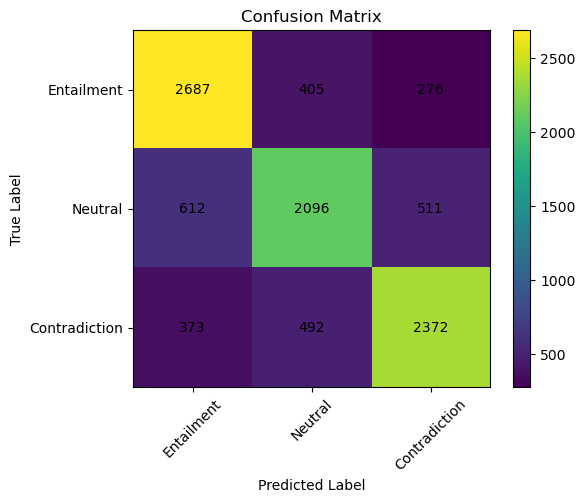

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix values
cm = np.array([
    [2687, 405, 276],
    [612, 2096, 511],
    [373, 492, 2372]
])

labels = ["Entailment", "Neutral", "Contradiction"]

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)  # for Markdown
plt.show()


In [29]:
import pandas as pd

report_df = pd.DataFrame({
    "Class": ["Entailment", "Neutral", "Contradiction", "Accuracy", "Macro Avg", "Weighted Avg"],
    "Precision": [0.7318, 0.7003, 0.7509, None, 0.7276, 0.7277],
    "Recall":    [0.7978, 0.6511, 0.7328, None, 0.7272, 0.7283],
    "F1-Score":  [0.7634, 0.6748, 0.7417, 0.7283, 0.7266, 0.7272],
    "Support":   [3368, 3219, 3237, 9824, 9824, 9824]
})

report_df


,Class,Precision,Recall,F1-Score,Support
0,Entailment,0.7318,0.7978,0.7634,3368
1,Neutral,0.7003,0.6511,0.6748,3219
2,Contradiction,0.7509,0.7328,0.7417,3237
3,Accuracy,NaN,NaN,0.7283,9824
4,Macro Avg,0.7276,0.7272,0.7266,9824
5,Weighted Avg,0.7277,0.7283,0.7272,9824
